In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [10]:
if_renormalon = False

In [33]:
result_set = {}
accuracies = ["N4LL"]
for XLL in accuracies:
    result_set[XLL] = pd.read_csv("result/fit_"+XLL+"_3.csv")

Import

In [34]:
import ast
def convert_to_list(string):
    corrected_string = string.replace("     ", ",")
    corrected_string = corrected_string.replace("    ", ",") 
    corrected_string = corrected_string.replace("   ", ",") 
    corrected_string = corrected_string.replace("  ", ",")    
    corrected_string = corrected_string.replace(" ", ",")
    l=len(corrected_string)
    new_string=""
    for i in range(1,l-1):
        if (corrected_string[i]=="," and (corrected_string[i-1]=="[" or corrected_string[i+1]=="]")):
            new_string = new_string
        else:
            new_string = new_string + corrected_string[i]

    new_string = new_string + "]"
    new_string = "[" + new_string

    return ast.literal_eval(new_string)

αs_set = {}
Ω1_set = {}
a_set = {}

for XLL in accuracies:
    results_df = result_set[XLL]
    αs_set[XLL] = results_df['αs'].to_numpy()
    params = results_df['params'].apply(convert_to_list)
    params = np.array(params.to_list())

    rows = len(params)
    cols = len(params[0])
    a_list = {}

    if if_renormalon == False:
        for i in range(cols):
            a_list[i] = params[:,i]
    if if_renormalon == True:
        Ω1_array = params[:,0]
        Ω1_set[XLL] = Ω1_array
        for i in range(cols-1):
            a_list[i] = params[:,i+1]
            
    a_set[XLL] = a_list

    #print(a_list)

In [35]:
for XLL in accuracies:
    αs_array = αs_set[XLL]
    print(XLL+" αs theoretical error is",round((max(αs_array)-min(αs_array))/2,5)) 

N4LL αs theoretical error is 0.00175


Correlation

In [36]:
data = {}
mean = {}
df_set = {}
cov_matrix = {}
std_devs = {}
corr_matrix = {}

for XLL in accuracies:
    
    data[XLL]={}
    mean[XLL]={}

    αs_array = αs_set[XLL]
    a_list = a_set[XLL]

    data[XLL]['αs'] = αs_array
    mean[XLL]["αs"] = np.mean(data[XLL]["αs"])
    l=len(a_list)
    for i in range(l):
        data[XLL][i+1] = a_list[i]
        mean[XLL][i+1] = np.mean(data[XLL][i+1])
    if if_renormalon == True:
        Ω1_array = Ω1_set[XLL]
        data[XLL]["Ω1"] = Ω1_array
        mean[XLL]["Ω1"] = np.mean(data[XLL]["Ω1"])  

    df_set[XLL]=pd.DataFrame(data[XLL])
    X = df_set[XLL].values

    cov_matrix[XLL] = np.cov(X, rowvar=False)
    std_devs[XLL] = np.sqrt(np.diag(cov_matrix[XLL]))
    corr_matrix[XLL] = cov_matrix[XLL] / np.outer(std_devs[XLL], std_devs[XLL])

for XLL in accuracies:
    display(XLL)
    display("mean:", mean[XLL])
    display("covariance matrix:", corr_matrix[XLL])
    display(df_set[XLL])

'N4LL'

'mean:'

{'αs': 0.1180884,
 1: 3.4984918000000005,
 2: -0.5645448,
 3: -0.21239180000000005}

'covariance matrix:'

array([[ 1.        , -0.52802753,  0.58703606, -0.46898719],
       [-0.52802753,  1.        , -0.89240983,  0.87011125],
       [ 0.58703606, -0.89240983,  1.        , -0.98609719],
       [-0.46898719,  0.87011125, -0.98609719,  1.        ]])

,αs,1,2,3
0,0.11836,3.46770,-0.42845,-0.25661
1,0.11711,3.75314,-1.06857,-0.05567
2,0.11846,3.40335,-0.29450,-0.29989
3,0.11746,3.59486,-0.87448,-0.11585
4,0.11816,3.26692,-0.14138,-0.36701
5,0.11932,3.38565,-0.21245,-0.29529
6,0.11870,3.35251,-0.20029,-0.31801
7,0.11770,3.59837,-0.87444,-0.09788
8,0.11767,3.63604,-0.91508,-0.10503
9,0.11838,3.53069,-0.67390,-0.18459


Plot

In [30]:
scale_68 = np.sqrt(2.279)
scale_95 = np.sqrt(5.991)

from matplotlib.patches import Ellipse
def draw_ellipse(mean, cov, scale, ax, **kwargs):

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    eigenvalues = 2.0 * scale * np.sqrt(eigenvalues)
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

    ell = Ellipse(xy=mean, width=eigenvalues[0], height=eigenvalues[1], angle=angle, **kwargs)
    
    ax.add_artist(ell)

In [31]:
data_set = {}

for XLL in accuracies:
    data_set[XLL] = df_set[XLL].copy()
    l = df_set[XLL].shape[0]
    XLL_series = pd.Series([XLL]*l)
    data_set[XLL]["XLL"] =  XLL_series

data_combined = pd.DataFrame()
df_c = pd.DataFrame()
for XLL in accuracies:
    data_combined = pd.concat([data_combined,data_set[XLL]],ignore_index=True)
    df_c = pd.concat([data_combined,df_set[XLL]],ignore_index=True)
display(data_combined)

,αs,1,2,3,XLL
0,0.11856,3.68390,-0.55121,-0.19628,N4LL
1,0.11722,3.96544,-1.03390,-0.05221,N4LL
2,0.11801,3.65794,-0.48782,-0.25568,N4LL
3,0.11778,3.76342,-0.82688,-0.11174,N4LL
4,0.11638,3.50567,-0.25411,-0.41619,N4LL
5,0.11768,3.83670,-0.91419,-0.09470,N4LL
6,0.11772,3.82690,-0.89933,-0.10420,N4LL
7,0.11825,3.70011,-0.62026,-0.19748,N4LL
8,0.11998,3.68617,-0.55093,-0.17286,N4LL
9,0.11975,3.68874,-0.56138,-0.17881,N4LL


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

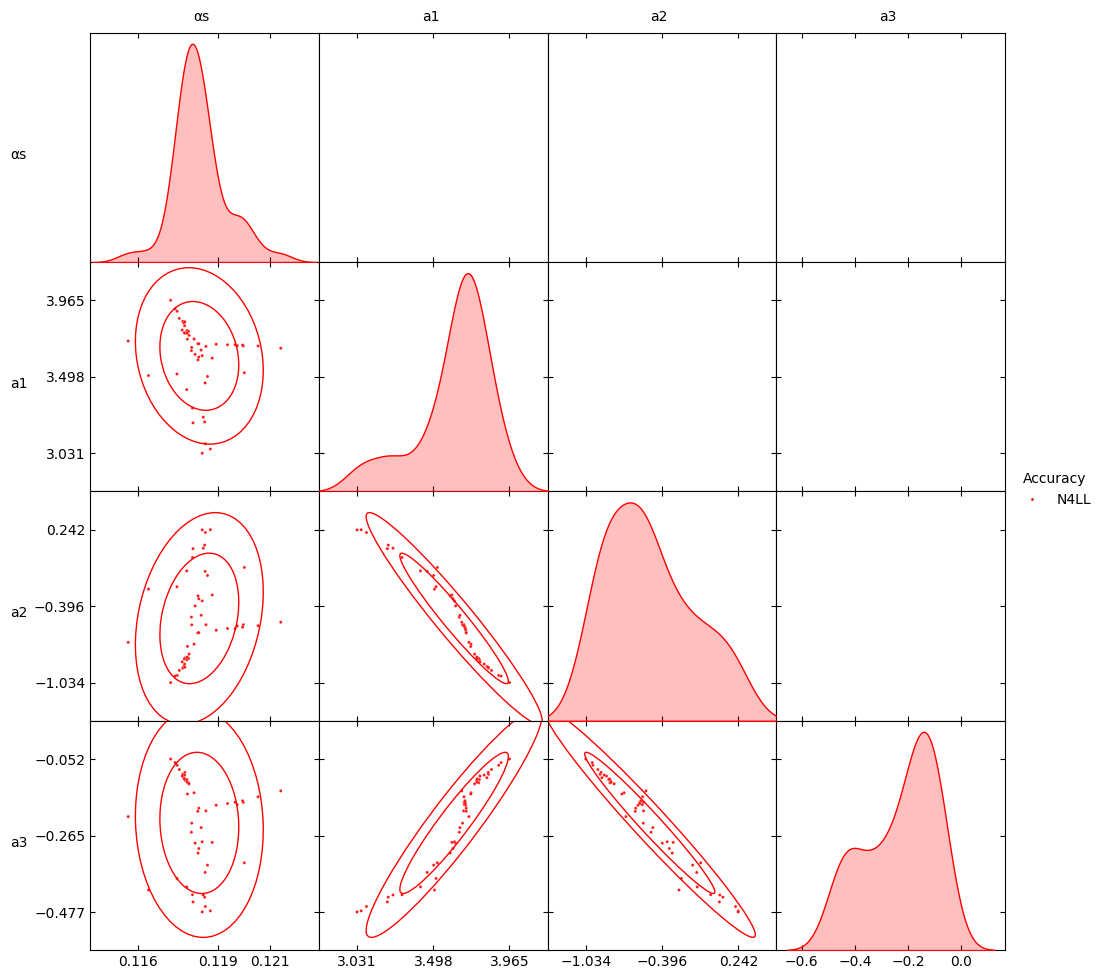

In [32]:
import seaborn as sns
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

color = ["red","orange","blue","cyan","purple"]
palette = {'N4LL': 'red', 'N3LL': 'orange', 'NNLL': 'blue'}
sizeOfFont = 10

data_set = {}

g = sns.PairGrid(data_combined, diag_sharey=False, hue='XLL', palette=palette)
g.map_lower(sns.scatterplot, s=5, alpha=0.9)
g.map_diag(sns.kdeplot, shade=True)
#g.map_diag(plt.hist)

k=0
for XLL in accuracies:

    df = df_set[XLL].copy()

    for i, j in zip(*np.tril_indices_from(g.axes, -1)):

        ax = g.axes[i, j]
        mean = df.mean().values[[j, i]]
        cov = np.cov(df.values.T[[j, i]])
        draw_ellipse(mean, cov, scale_68, ax, edgecolor=color[k], fc='None')
        draw_ellipse(mean, cov, scale_95, ax, edgecolor=color[k], fc='None')

        #--------------------------------------------------------------------------
        deltax=max(df_c.values.T[j])-min(df_c.values.T[j])
        deltay=max(df_c.values.T[i])-min(df_c.values.T[i])
        minx=min(df_c.values.T[j])
        miny=min(df_c.values.T[i])

        ax.set_xlim(minx-0.25*deltax,max(df.values.T[j])+0.25*deltax)
        ax.set_ylim(miny-0.25*deltay,max(df.values.T[i])+0.25*deltay)
        n=3
        ax.set_xticks([round(minx,n),round(minx+deltax/2,n),round(minx+deltax,n)])
        ax.set_yticks([round(miny,n),round (miny+deltay/2,n),round(miny+deltay,n)])
        #--------------------------------------------------------------------------

    k=k+1

for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(direction='in', top=True, right=True, labelsize = sizeOfFont)
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)
        ax.set_xlabel('')
        ax.set_ylabel('')

names=["αs","a1","a2","a3"]
props = dict(boxstyle='round', facecolor='white', alpha=0)
i=0
for ax in g.axes[0, :]:
    ax.text(0.45, 1.1,  names[i], transform=ax.transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
    i=i+1
j=0
for ax in g.axes[:, 0]:
    ax.text(-0.35, 0.5,  names[j], transform=ax.transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
    j=j+1

g.axes[0, 0].set_yticks([])
#g.axes[3, 3].set_xticks([])

plt.subplots_adjust(wspace=0.0, hspace=0.0)
legend = g.add_legend(title="Accuracy")
plt.show()